<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_13_Pooling_Transformation_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import  nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
import urllib.request
from matplotlib.pyplot import imshow
from torch.utils.data import  *
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import seaborn as sns






In [2]:
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
x_example, y_example = mnist_data_train[0]
print(x_example.shape)

torch.Size([1, 28, 28])


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

B = 32
mnist_train_loader = DataLoader(mnist_data_train, batch_size=B, shuffle=True)
mnist_test_loader = DataLoader(mnist_data_test, batch_size=B)

In [4]:
print(device)

cuda


In [5]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28*28 #28 * 28 images
#How many channels are in the input?
C = 1
#How many classes are there?
classes = 10
#How many filters should we use. The network learns 16 different filters, each trying to detect a different pattern (edges, blobs, strokes, etc.).
filters = 16
#how large should our filters be?
K = 3
#for comparison, lets define a linear model of similar complexity
model_linear = nn.Sequential(
  nn.Flatten(), #(B, C, W, H) -> (B, C*W*H) = (B,D)
  nn.Linear(D, 256),
  nn.Tanh(),
  nn.Linear(256, classes),
)

#A simple convolutional network:
model_cnn = nn.Sequential(
  #Conv2d follows the pattern of:
  #Conv2d(# of input channels, #filters/output-channels, #filter-size)
  nn.Conv2d(C, filters, K, padding=K//2), #$x \circledast G$
  nn.Tanh(),#Activation functions work on any size tensor
  nn.Flatten(), #Convert from (B, C, W, H) ->(B, D). This way we can use a Linear layer after
  nn.Linear(filters*D, classes),
)

In [6]:
def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()
    for inputs, labels in tqdm(data_loader, desc=desc, leave=False):
        #Move the batch to the device we are using.
        inputs = inputs.to(device)
        labels = labels.to(device)

        y_hat = model(inputs) #this just computed f_Θ(x(i))
        # Compute loss.
        loss = loss_func(y_hat, labels)

        if model.training: #check the flag
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        #Now we are just grabbing some information we would like to have
        running_loss.append(loss.item())

        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            #moving labels & predictions back to CPU for computing / storing predictions
            labels = labels.detach().cpu().numpy() # we have this info in the slides. Please remember why I am detaching
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()

    y_pred = np.asarray(y_pred)
    if len(y_pred.shape) == 2 and y_pred.shape[1] > 1: #We have a classification problem, convert to labels
        y_pred = np.argmax(y_pred, axis=1)
    #Else, we assume we are working on a regression problem

    results[prefix + " loss"].append( np.mean(running_loss) )
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )
        except:
            results[prefix + " " + name].append(float("NaN"))
    return end-start

In [7]:
def train_simple_network(model, loss_func, train_loader, test_loader=None, score_funcs=None,epochs=50, device="cpu", checkpoint_file=None):

    to_track = ["epoch", "total time", "train loss"] #Bookkeeping. These are what I want to track.

    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if test_loader is not None:
            to_track.append("test " + eval_score )

    total_train_time = 0 #How long have we spent in the training loop?
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []

    #SGD is Stochastic Gradient Decent.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device) #this will keep this in cpu unless you have GPU available and indicate it in the function call

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()#Put our model in training mode

        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )

        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")

    if checkpoint_file is not None:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'results' : results
            }, checkpoint_file)

    return pd.DataFrame.from_dict(results)


In [8]:
loss_func = nn.CrossEntropyLoss()

In [9]:
#fc_results = train_simple_network(model_linear, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)

In [10]:
cnn_results = train_simple_network(model_cnn, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)


Training:  96%|██████████████████████████▊ | 1795/1875 [00:02<00:00, 708.35it/s]
                                                                                
Training:  97%|███████████████████████████▎| 1828/1875 [00:01<00:00, 963.52it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1846/1875 [00:02<00:00, 763.83it/s]
                                                                                
Training:  98%|███████████████████████████▍| 1839/1875 [00:01<00:00, 972.52it/s]
                                                                                
Training:  98%|███████████████████████████▍| 1837/1875 [00:02<00:00, 805.39it/s]
                                                                                
Training:  97%|███████████████████████████ | 1810/1875 [00:01<00:00, 949.18it/s]
                                                                                
Training: 100%|█████████████

<Axes: xlabel='epoch', ylabel='test Accuracy'>

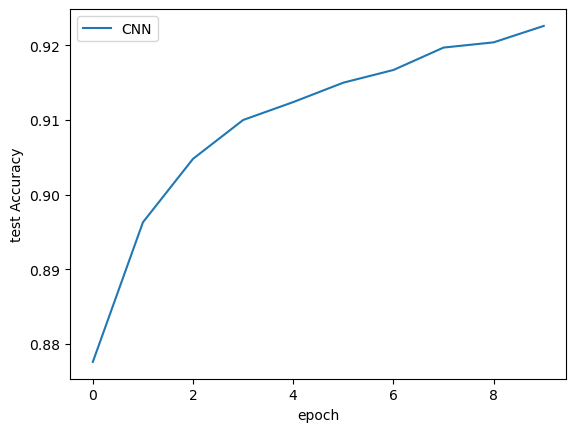

In [11]:
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')
#sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Fully Conected')

In [12]:
cnn_results.columns

Index(['epoch', 'total time', 'train loss', 'test loss', 'train Accuracy',
       'test Accuracy'],
      dtype='object')

<Axes: xlabel='epoch', ylabel='train loss'>

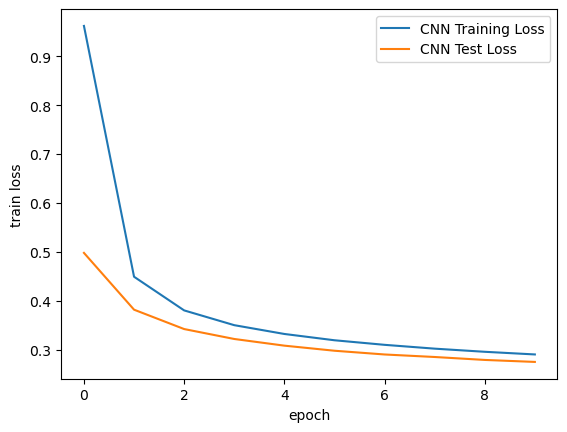

In [13]:

sns.lineplot(x='epoch', y='train loss', data=cnn_results, label='CNN Training Loss')
sns.lineplot(x='epoch', y='test loss', data=cnn_results, label='CNN Test Loss')

# Max Pooling

Manipulate images and try to predict


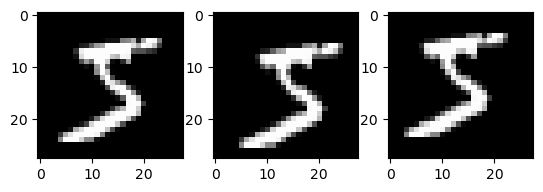

In [14]:
img_indx = 0
img, correct_class = mnist_data_train[img_indx]
img = img[0,:]
#move to the lower right, then upper left
img_lr = np.roll(np.roll(img, 1, axis=1), 1, axis=0)
img_ul = np.roll(np.roll(img, -1, axis=1), -1, axis=0)
#plot the images
f, axarr = plt.subplots(1,3)
axarr[0].imshow(img, cmap='gray')
axarr[1].imshow(img_lr, cmap='gray')
axarr[2].imshow(img_ul, cmap='gray')
plt.show()

It's prediction time.


* "eval" mode since we are not training.
* Always turn off gradients when evaluating

In [15]:

model = model_cnn.cpu().eval()

def pred(model, img):
    with torch.no_grad():
        w, h = img.shape#Whats the width/height of the image
        if not isinstance(img, torch.Tensor):
            img = torch.tensor(img)
        x = img.reshape(1,-1,w,h)#reshape it as (B, C, W, H)
        logits = model(x) #Get the logits
        y_hat = F.softmax(logits, dim=1)#Turn into probabilities
        return y_hat.numpy().flatten()#convert prediction to numpy array.

Modified images tested here

In [16]:
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob:         ".format(correct_class) , img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class) , img_lr_pred[correct_class])
print("Uper Left Img Class {} Prob:   ".format(correct_class) , img_ul_pred[correct_class])

Org Img Class 5 Prob:          0.7384548
Lower Right Img Class 5 Prob:  0.3547238
Uper Left Img Class 5 Prob:    0.2664444


Implementing Pooling in an updated code

In [17]:
model_cnn_pool = nn.Sequential(
  nn.Conv2d(C, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),

  nn.Flatten(),
  #Why did we reduce the number of units into the Linear layer by a factor of $4^2$?
  #Because pooling a 2x2 grid down to one value means we go from 4 values, down to 1, and we did this two times.
  nn.Linear(2*filters*D//(4**2), classes),
)

cnn_results_with_pool = train_simple_network(model_cnn_pool, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)


Training:  97%|███████████████████████████▎| 1827/1875 [00:03<00:00, 587.09it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1851/1875 [00:03<00:00, 587.22it/s]
                                                                                
Training:  99%|███████████████████████████▌| 1847/1875 [00:03<00:00, 591.11it/s]
                                                                                
Training:  99%|███████████████████████████▊| 1862/1875 [00:03<00:00, 480.06it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1854/1875 [00:03<00:00, 587.37it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1844/1875 [00:03<00:00, 585.48it/s]
                                                                                
Training:  98%|█████████████

In [18]:
model = model_cnn_pool.cpu().eval()
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob:         ".format(correct_class) , img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class) , img_lr_pred[correct_class])
print("Uper Left Img Class {} Prob:   ".format(correct_class) , img_ul_pred[correct_class])

Org Img Class 5 Prob:          0.545779
Lower Right Img Class 5 Prob:  0.78438574
Uper Left Img Class 5 Prob:    0.33709508


<Axes: xlabel='epoch', ylabel='test Accuracy'>

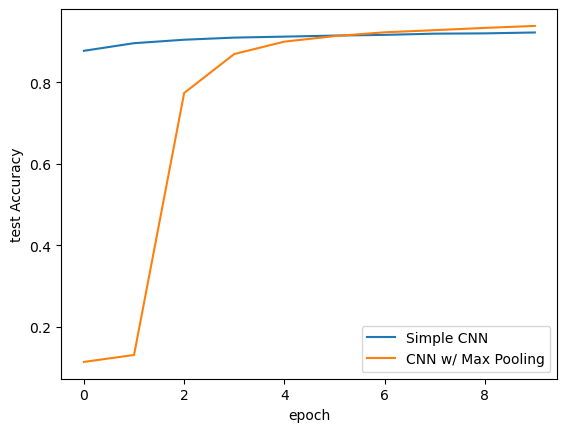

In [19]:
import seaborn as sns
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='Simple CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN w/ Max Pooling')

# Transforms

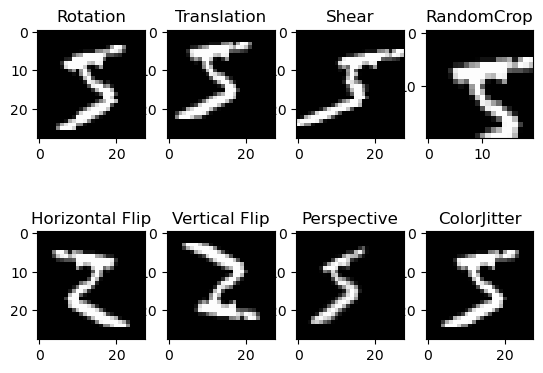

In [20]:
#Several built-in transformations, given some agressive values to make their impact more obvious.
sample_transforms = {
    "Rotation" : transforms.RandomAffine(degrees=45),
    "Translation" : transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    "Shear": transforms.RandomAffine(degrees=0, shear=45),
    "RandomCrop" : transforms.RandomCrop((20,20)),
    "Horizontal Flip" : transforms.RandomHorizontalFlip(p=1.0),
    "Vertical Flip": transforms.RandomVerticalFlip(p=1.0),
    "Perspective": transforms.RandomPerspective(p=1.0),
    "ColorJitter" : transforms.ColorJitter(brightness=0.9, contrast=0.9)
}
#Convert the Tensor image back to a PIL image using a transform
pil_img = transforms.ToPILImage()(img)
#Plot a randomy application of each transform
f, axarr = plt.subplots(2,4)
for count, (name, t) in enumerate(sample_transforms.items()):
    row = count % 4
    col = count // 4
    axarr[col,row].imshow(t(pil_img), cmap='gray')
    axarr[col,row].set_title(name)
plt.show()

Get the data and apply transformations

In [21]:
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.98, 1.02)),
    transforms.ToTensor(),
])

test_transform = transforms.ToTensor()

mnist_train_t = torchvision.datasets.MNIST("./data", train=True, transform=train_transform)
mnist_test_t = torchvision.datasets.MNIST("./data", train=False, transform=test_transform)
mnist_train_loader_t = DataLoader(mnist_train_t, shuffle=True,  batch_size=B, num_workers=5)
mnist_test_loader_t = DataLoader(mnist_test_t, batch_size=B, num_workers=5)

In [22]:
model_cnn_pool = nn.Sequential(
  nn.Conv2d(C, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),
  nn.Flatten(),
  nn.Linear(2*filters*D//(4**2), classes),
)

In [23]:
cnn_results_with_pool_augmented = train_simple_network(model_cnn_pool, loss_func, mnist_train_loader_t, test_loader=mnist_test_loader_t, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)

Training:  97%|███████████████████████████ | 1811/1875 [00:02<00:00, 769.85it/s]
                                                                                
Training:  97%|███████████████████████████ | 1810/1875 [00:02<00:00, 760.05it/s]
                                                                                
Training:  98%|███████████████████████████▍| 1838/1875 [00:02<00:00, 662.44it/s]
                                                                                
Training:  99%|███████████████████████████▌| 1848/1875 [00:02<00:00, 736.18it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1844/1875 [00:02<00:00, 710.89it/s]
                                                                                
Training:  98%|███████████████████████████▎| 1832/1875 [00:02<00:00, 724.62it/s]
                                                                                
Training:  99%|█████████████

Let's compare accuracies again

<Axes: xlabel='epoch', ylabel='test Accuracy'>

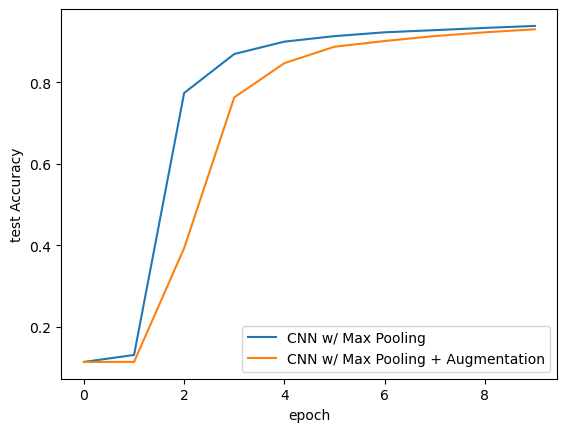

In [24]:
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN w/ Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool_augmented, label='CNN w/ Max Pooling + Augmentation')

In [25]:
model = model_cnn_pool.cpu().eval()
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob:         ".format(correct_class) , img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class) , img_lr_pred[correct_class])
print("Uper Left Img Class {} Prob:   ".format(correct_class) , img_ul_pred[correct_class])

Org Img Class 5 Prob:          0.65019214
Lower Right Img Class 5 Prob:  0.7526833
Uper Left Img Class 5 Prob:    0.57751554


# Question
Can you modify some transform parameters and see if there are any changes?

Training:  96%|██████████████████████████▉ | 1804/1875 [00:02<00:00, 729.10it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1851/1875 [00:02<00:00, 713.51it/s]
                                                                                
Training: 100%|███████████████████████████▊| 1866/1875 [00:02<00:00, 618.36it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1844/1875 [00:02<00:00, 703.06it/s]
                                                                                
Training: 100%|███████████████████████████▉| 1869/1875 [00:02<00:00, 684.10it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1843/1875 [00:02<00:00, 738.33it/s]
                                                                                
Training:  97%|█████████████

Org Img Class 5 Prob:          0.34335843
Lower Right Img Class 5 Prob:  0.4921575
Uper Left Img Class 5 Prob:    0.22913454


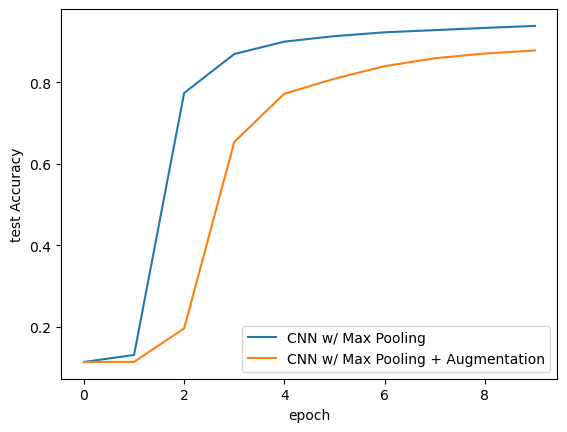

In [26]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.98, 1.02)),
    transforms.ToTensor(),
])

test_transform = transforms.ToTensor()

mnist_train_t = torchvision.datasets.MNIST("./data", train=True, transform=train_transform)
mnist_test_t = torchvision.datasets.MNIST("./data", train=False, transform=test_transform)
mnist_train_loader_t = DataLoader(mnist_train_t, shuffle=True,  batch_size=B, num_workers=5)
mnist_test_loader_t = DataLoader(mnist_test_t, batch_size=B, num_workers=5)

model_cnn_pool = nn.Sequential(
  nn.Conv2d(C, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(filters, filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),
  nn.Conv2d(filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.Conv2d(2*filters, 2*filters, 3, padding=3//2),
  nn.Tanh(),
  nn.MaxPool2d(2),
  nn.Flatten(),
  nn.Linear(2*filters*D//(4**2), classes),
)

cnn_results_with_pool_augmented = train_simple_network(model_cnn_pool, loss_func, mnist_train_loader_t, test_loader=mnist_test_loader_t, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool, label='CNN w/ Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results_with_pool_augmented, label='CNN w/ Max Pooling + Augmentation')

model = model_cnn_pool.cpu().eval()
img_pred = pred(model, img)
img_lr_pred = pred(model, img_lr)
img_ul_pred = pred(model, img_ul)

print("Org Img Class {} Prob:         ".format(correct_class) , img_pred[correct_class])
print("Lower Right Img Class {} Prob: ".format(correct_class) , img_lr_pred[correct_class])
print("Uper Left Img Class {} Prob:   ".format(correct_class) , img_ul_pred[correct_class])
